In [3]:
import numpy as np
import matplotlib.pyplot as plt
import random

def setup_tridiagonal_matrix(x, y):

    n = len(x)

    h = np.diff(x)  # Step sizes between data points

    # Initialize the tridiagonal matrix coefficients

    A = np.zeros(n - 2)  # Subdiagonal
    B = np.zeros(n - 2)  # Main diagonal
    C = np.zeros(n - 2)  # Superdiagonal
    D = np.zeros(n - 2)  # Right-hand side vector

    # Populate the tridiagonal matrix coefficients

    for i in range(1, n - 1):

        A[i - 1] = h[i-1]           # Subdiagonal
        B[i - 1] = 2*(h[i-1]+h[i])         # Main diagonal
        C[i - 1] = h[i]             # Superdiagonal
        D[i - 1] = 6*((y[i+1]-y[i])/h[i] - (y[i]-y[i-1])/h[i-1])         # Right-hand side vector

    return A, B, C, D

def thomas_algorithm(a, b, c, d):
    """
    Solve the tridiagonal system using the Thomas algorithm.
    a: sub-diagonal elements (length n-1)
    b: main diagonal elements (length n)
    c: super-diagonal elements (length n-1)
    d: right-hand side (length n)
    Returns: solution vector x of length n
    """
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
        
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x

def evaluate_spline(x_data, y_data, M, x_query):
    """M: second derivatives; M[0]=M[-1]=0 for natural spline"""
    n = len(x_data)
    h = np.diff(x_data) # step sizes
    
    i = np.searchsorted(x_data, x_query, side='right') - 1
    i = np.clip(i, 0, n - 2) # find interval
    
    hi = h[i]
    dx_left = x_query - x_data[i] # (x - xᵢ)
    dx_right = x_data[i+1] - x_query # (xᵢ₊₁ - x)
    S = (
        (M[i] / (6*hi)) * dx_right**3 + # Term 1
        (M[i+1] / (6*hi)) * dx_left**3 + # Term 2
        (y_data[i] /hi - M[i] *hi/6) * dx_right + # Term 3
        (y_data[i+1] /hi - M[i+1] *hi/6) * dx_left # Term 4
    )
    return S

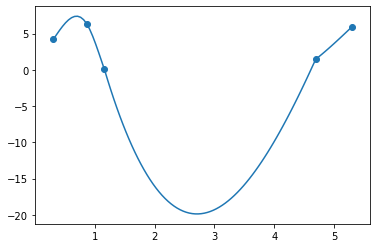

In [14]:
N = 5
x_data = np.zeros(N)
for i in range (0, N):
    x_data[i] = random.uniform(0, 10)
x_data = np.sort(x_data)
y_data = np.zeros(N)
for i in range (0, N):
    y_data[i] = random.uniform(0, 10)
    
A, B, C, D = setup_tridiagonal_matrix(x_data, y_data)

M_inner = thomas_algorithm(A, B, C, D)
M_data = np.zeros(N)
M_data[1:-1] = M_inner

x_graph = np.linspace(np.min(x_data), np.max(x_data), 100)

plt.plot(x_graph, evaluate_spline(x_data, y_data, M_data, x_graph))
plt.scatter(x_data, y_data)